In [7]:
import numpy as np
import pandas as pd

### Logistic Regression

In [11]:
#sigmoid Function
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [13]:
#CrossEntropy loss function:
#Cross-entropy loss is low when the model is confident and correct, and high when it is confident and wrong. 
#The negative log amplifies incorrect, confident predictions — encouraging the model to assign high probability to the correct class.
# so if y = 1; -log(0.99) ~ 0; -log(0.01) > 4.5 very high; -log(0.4) ~ 0.96
def compute_loss(y_true,y_pred):
    epsilon = 1e-15
    y_pred=np.clip(y_pred,epsilon,1-epsilon)
    return -np.mean(y_true*np.log(y_pred)+(1-y_true)*np.log(1-y_pred))

In [15]:
def gradient_descent(X, y, w, b, lr):
    m = X.shape[0]
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)

    dw = np.dot(X.T, (y_pred - y)) / m
    db = np.mean(y_pred - y)

    w -= lr * dw
    b -= lr * db

    return w, b, compute_loss(y, y_pred)

In [17]:
def predict(X, w, b):
    z = np.dot(X, w) + b
    return (sigmoid(z) >= 0.5).astype(int)

In [19]:
#dataPrep
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

# Binary classification only (class 0 vs 1)
mask = y < 2
X = X[mask]
y = y[mask]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize
# If you normalize before splitting:You leak test data stats (mean/std) into training;This causes data leakage
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

In [43]:
# Training
m, n = X_train.shape
w = np.zeros(n)
b = 0
lr = 0.1
epochs = 1000

for i in range(epochs):
    w, b, loss = gradient_descent(X_train, y_train, w, b, lr)
    if i%500 == 0:
        print(f"Epoch {i} – Loss: {loss:.4f}")    

Epoch 0 – Loss: 0.6931
Epoch 500 – Loss: 0.0112


In [23]:
#Evaluate
y_pred = predict(X_test, w, b)
acc = np.mean(y_pred == y_test)
print("Test Accuracy:", acc)

Test Accuracy: 1.0


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Feature columns
num_cols = ['age', 'income']
cat_cols = ['city', 'gender']

# 2. Preprocessing transformers
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# 3. Final pipeline
pipe = Pipeline([
    ('pre', preprocessor),
    ('logreg', LogisticRegression(solver='liblinear', max_iter=1000))
])

# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 5. Cross-validation *only on training set*
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')

print("Cross-Validated Accuracy:", scores)
print("Mean CV Accuracy:", scores.mean())

# 6. Final fit + test set evaluation
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))


In [ ]:
### 🧪 ML Classification Pipeline – Iris Dataset (Logistic Regression)
#### Step 1: Load & Inspect Data 
#### Step 2: Preprocessing:  check for nulls; Convert categorical;- Apply `StandardScaler` for feature scaling
#### Step 3: Train/Test Split - Use `train_test_split` from `sklearn` - Typical split: 80% train / 20% test
#### Step 4: Build Pipeline: - Use `Pipeline()` from `sklearn.pipeline` - Steps: Scaling → Logistic Regression
#### Step 5: Train Model - Fit pipeline on training data
#### Step 6: Evaluate Performance - Use `classification_report`- Print accuracy, precision, recall, F1
#### Step 7: Cross-Validation - Use `cross_val_score` with 5-fold CV;;- Measure mean and std of scores 
#### Step 8: Save the Model :- Use `joblib.dump()` to persist the trained pipeline

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Example columns
num_cols = ['age', 'income']
cat_cols = ['gender', 'city']

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

pipeline = Pipeline([
#    ('preprocess', preprocessor),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression())
])

In [42]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

mask = y < 2
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('lr', LogisticRegression())])

In [49]:
from sklearn.metrics import classification_report

y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [51]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipeline, X, y, cv=5)
print("CV Accuracy:", scores.mean())

CV Accuracy: 1.0


In [53]:
import joblib
joblib.dump(pipeline, 'logistic_pipeline.pkl')

['logistic_pipeline.pkl']

### 🔹 Logistic is still linear 
Logistic Regression is a linear model — because it models the log-odds as a linear function of the input:
The S-curve only happens in the output space (probability),but the decision boundary — where the model flips class —
is still a straight line or hyperplane in feature space.

### 🔹 Why Sigmoid?
Logistic Regression doesn’t predict probabilities directly.It assumes that the log-odds of the target class can be modeled as a linear combination of input features.Why log-odds? Because odds explode non-linearly, but log-odds grow smoothly and can be modeled with a straight line.Once we get the log-odds using we apply the sigmoid function to squash that into a value between 0 and 1 —
which gives us a valid probability.

| Probability (p) | Odds = p / (1−p) | 🚫 Multiplicative Growth | Log-Odds = log(p / (1−p)) | ✅ Linear Growth |
|-----------------|------------------|---------------------------|-----------------------------|------------------|
| 0.50            | 1                | Baseline                  | 0                           | Baseline         |
| 0.80            | 4                | ×4                        | 1.39                        | +1.39            |
| 0.90            | 9                | ×9                        | 2.20                        | +0.81            |
| 0.99            | 99               | ×99                       | 4.59                        | +2.39            |
| 0.999           | 999              | ×999                      | 6.90                        | +2.31            |

### 🔹 Why Not MSE?
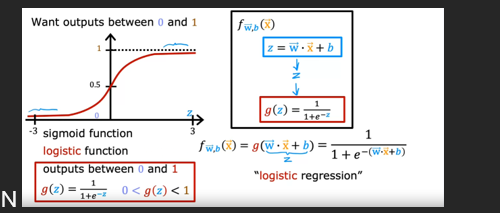
MSE assumes a straight line between prediction and truth.But in Logistic Regression, the output is a probability between 0 and 1, curved by sigmoid.Using MSE on that curve gives messy, unstable gradients — slow learning, bad convergence.
Instead: Binary cross-entropy is designed for probabilities — it punishes confident wrong guesses and gives clean, sharp gradients for updates.

### 🔹 Decision Boundary
Occurs when $$\hat{y} = 0.5  ;;; 
w^T x + b = 0
$$
Understanding why sigmoid(0) = 0.5 is the decision boundary lets you:
Defend your model’s output logic;Interpret prediction confidence;Tune thresholds intelligently in skewed datasets
### 🔹 Limitations
- Linear decision boundary only - Can’t handle non-linear patterns - Sensitive to feature scaling
- Performance degrades with multicollinearity
### 🔹 Regularization:
Add a regularization term to the loss → model can't get away with extreme weights.It must now balance:Fitting the data well
Keeping weights small (or sparse)

|                        | **L1 Regularization (Lasso)**             | **L2 Regularization (Ridge)**            |
|------------------------|--------------------------------------------|-------------------------------------------|
| **Penalty Term**       | λ × sum of absolute weights: ∑ |wᵢ|        | λ × sum of squared weights: ∑ wᵢ²         |
| **Effect**             | Makes some weights exactly 0               | Shrinks all weights, but keeps all        |
| **Gradient**           | Non-smooth (not differentiable at 0)       | Smooth and differentiable                 |
| **Feature Selection**  | ✅ Yes – automatic                         | ❌ No                                      |
| **Use Case**           | Sparse models, high-dimensional data       | General shrinkage, multicollinearity      |


### 🔹 Multiclass Extension
- Use **One-vs-Rest** or **Softmax Regression**


| Step | Description | Formula |
|------|-------------|---------|
| 1 | **Predicted Probability** | $$\hat{y} = \sigma(w^T x + b) = \frac{1}{1 + e^{-w^T x + b}}$$ |
| 2 | **Bernoulli Likelihood** | $$P(y \mid x) = \hat{y}^y (1 - \hat{y})^{1 - y}$$ |
| 3 | **Log-Likelihood** | $$\log \mathcal{L} = \sum \left[ y \log(\hat{y}) + (1 - y)\log(1 - \hat{y}) \right]$$ |
| 4 | **Negative Log-Likelihood (Loss)** | $$\mathcal{L} = -\frac{1}{m} \sum \left[ y \log(\hat{y}) + (1 - y)\log(1 - \hat{y}) \right]$$ |

| Sigmoid | Prediction | Loss (BCE) | Gradient w.r.t w | Gradient w.r.t b | Update Rule |
|--------|------------|------------|------------------|------------------|-------------|
| $$\sigma(z) = \frac{1}{1 + e^{-z}}$$ | $$\hat{y} = \sigma(w^T x + b)$$ | $$-\frac{1}{m} \sum [y \log \hat{y} + (1 - y) \log(1 - \hat{y})]$$ | $$\frac{1}{m} X^T(\hat{y} - y)$$ | $$\frac{1}{m} \sum (\hat{y} - y)$$ | $$w := w - \alpha \cdot \nabla w, \quad b := b - \alpha \cdot \nabla b$$ |

| Question | Why It Matters |
|----------|----------------|
| **How does LR behave under multicollinearity?** | Coefficients become unstable; regularization (L2) helps control it |
| **What happens if features are correlated with each other and the target?** | Model may overweight one and underweight others; results can be misleading |
| **How does LR compare to Naive Bayes?** | NB assumes feature independence; LR is more flexible and typically better calibrated |
| **How do you interpret LR coefficients?** | Each coefficient represents the change in **log-odds** per unit change in that feature |
| **How to model non-linear relationships in LR?** | You must manually add polynomial or interaction terms — LR can’t do it natively |
| **How does class imbalance affect LR?** | LR will favor the majority class; fix with `class_weight`, resampling, or threshold tuning |
| **When does LR fail completely?** | When the classes are **not linearly separable** (e.g. XOR pattern) |
| **Can LR overfit?** | Yes — especially in high-dimensional data without regularization (L1/L2) |


# 🧠 Top 40 ML Foundational Questions (Interview-Grade)

In [ ]:
## 🔹 Core Theory
### 2. Why is feature scaling important?
- Ensures features contribute equally and improves convergence in gradient-based models.
### 3. What is the sigmoid function used for?
- Maps output to [0,1] range for probabilities in logistic regression.
### 4. Why not use MSE for classification?
- BCE gives convex loss for classification; MSE leads to poor gradients and slower convergence.
### 5. What is the bias-variance tradeoff?
- High bias underfits, high variance overfits; goal is balanced generalization.
### 6. What causes overfitting?
- Model memorizes noise in training data; high train accuracy but low test accuracy.
### 7. What is underfitting?
- Model is too simple to capture patterns; both train and test accuracy are low.
### 8. What is data leakage?
- When test/val info leaks into train, causing inflated performance.
### 9. What is precision vs recall?
- Precision = TP / (TP + FP) → How correct positives are.
- Recall = TP / (TP + FN) → How many actual positives were found.
### 10. Why split into train/val/test?
- Train: fit model  
- Val: tune hyperparams  
- Test: final unbiased evaluation
## 🔹 Applied ML Ops
### 11. What is cross-validation?
- Resample data into k-folds to validate on unseen data and reduce variance.
### 12. What is early stopping?
- Stop training when val loss increases to avoid overfitting.
### 13. What is model drift?
- Model performance drops due to changes in data distribution over time.
### 14. Difference: data drift vs concept drift?
- Data drift: input X changes  
- Concept drift: relation between X and y changes
### 15. What is batch vs real-time inference?
- Batch: predictions in groups  
- Real-time: instant predictions, low latency required
### 16. How do you detect overfitting during training?
- Training loss ↓ but validation loss ↑.
### 17. How do you prevent overfitting?
- Regularization, cross-validation, early stopping, dropout, more data.
### 18. What is the role of validation set?
- Used to tune model and hyperparameters without touching test set.
### 19. Why save your model?
- To deploy or reuse it for inference without retraining.
### 20. What is a pipeline in ML?
- A sequence of preprocessing, transformation, and modeling steps combined for reuse.
## 🔹 Deep Learning Specific
### 21. Why use ReLU over sigmoid?
- ReLU avoids vanishing gradients, is sparse, and trains faster.
### 22. What is dropout?
- Randomly deactivates neurons during training to prevent overfitting.
### 23. Dropout vs L2 regularization?
- Dropout prevents co-adaptation of neurons; L2 shrinks weights.
### 24. What is attention mechanism?
- Dynamically weighs input elements, useful in seq2seq models (e.g., Transformers).
### 25. What is the softmax function?
- Converts raw logits to class probabilities for multiclass classification.
### 26. What is the difference: softmax vs sigmoid?
- Sigmoid: independent [0,1] per class  
- Softmax: probabilities sum to 1 for mutually exclusive classes
### 27. What is an embedding?
- Dense vector representation of categorical inputs (like words) in continuous space.
### 28. Embedding vs One-Hot?
- One-hot: sparse, high-dim  
- Embedding: dense, low-dim, learned during training
### 29. What is positional encoding?
- Adds order info to input embeddings in Transformer models.
### 30. What is vanishing gradient?
- Gradients become too small in deep nets, slowing or stalling learning.
## 🔹 Evaluation & Metrics
### 31. What is AUC-ROC?
- Measures classifier’s ability to separate classes; plots TPR vs FPR.
## 32. When is F1 score better than accuracy?
- When classes are imbalanced; F1 balances precision and recall.
### 33. What is class imbalance?
- When one class dominates the dataset; leads to biased learning.
### 34. How do you handle class imbalance?
- Weighted loss, SMOTE, oversampling/undersampling, stratified CV.
### 35. What is confusion matrix?
- Matrix showing TP, FP, FN, TN counts to analyze classifier performance.
### 36. What is log loss?
- Logistic loss = negative log-likelihood for predicted class probability.
### 37. What is overfitting on validation set?
- When model is tuned so much to val set that it no longer generalizes to test.
### 38. What is feature selection?
- Process of selecting the most informative features to improve model performance.
### 39. What is the curse of dimensionality?
- As features increase, data becomes sparse and distance-based models degrade.
### 40. What is model interpretability?
- Ability to understand how/why a model made a prediction (e.g., SHAP, LIME).

 C:\Users\vjs\Desktop\JobSearch\ReviewNB\ML>jupyter nbconvert LogisticRegression.ipynb --to html --template classic